In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlss-sp-25/sample_submission.csv
/kaggle/input/mlss-sp-25/train.csv
/kaggle/input/mlss-sp-25/test.csv


In [2]:
train = pd.read_csv("/kaggle/input/mlss-sp-25/train.csv")
test = pd.read_csv("/kaggle/input/mlss-sp-25/test.csv")

In [3]:
import warnings
warnings.filterwarnings("ignore", category = RuntimeWarning)
from sklearn.model_selection import GridSearchCV, train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train.head()

,object_id,transaction_currency,height_cm,width_cm,location,category,date,n_previous_owners,creation_year,is_titled,signed,dated,n_exhibited,artist_birth_year,artist_death_year,estimate,price_realized
0,yzkxu,USD,67.3,55.9,New York,Paintings,2008-01-11,4.0,1996.0,NaN,True,True,0,1937.0,NaN,15000.0,9375.0
1,iponc,USD,122.2,122.2,New York,Paintings,2008-01-11,1.0,NaN,False,True,True,0,1952.0,NaN,2500.0,3750.0
2,ybhua,USD,15.2,10.2,New York,Paintings,2008-01-11,2.0,NaN,True,True,True,2,1958.0,NaN,6000.0,11250.0
3,koiua,USD,58.4,67.3,New York,Paintings,2008-01-11,2.0,NaN,False,True,True,0,1973.0,NaN,5000.0,9375.0
4,wynxu,USD,68.6,52.7,New York,Paintings,2008-01-11,1.0,1957.0,NaN,True,False,0,1917.0,NaN,25000.0,15000.0


In [5]:
train.isnull().sum()

object_id                   0
transaction_currency        0
height_cm               21700
width_cm                21700
location                 1879
category                    0
date                        0
n_previous_owners       42334
creation_year           75552
is_titled               88123
signed                      0
dated                       0
n_exhibited                 0
artist_birth_year       16253
artist_death_year       32964
estimate                   84
price_realized              0
dtype: int64

In [6]:
test.isnull().sum()

object_id                   0
transaction_currency        0
height_cm                4173
width_cm                 4173
location                    0
category                    0
date                        0
n_previous_owners        9077
creation_year           27382
is_titled               40819
signed                      0
dated                       0
n_exhibited                 0
artist_birth_year        4967
artist_death_year       16044
estimate                   82
dtype: int64

The 'creation_year' and 'is_titled' has more than 50% null values, so the best option is to drop them.

In [7]:
train = train.drop(['creation_year', 'is_titled'], axis = 1)
test = test.drop(['creation_year', 'is_titled'], axis = 1)

In [8]:
def clean_numeric(value):
    try:
        return float(value)
    except:
        return None

train = train.copy()
test = test.copy()

train.loc[:, 'height_cm'] = train['height_cm'].apply(clean_numeric)
train.loc[:, 'width_cm'] = train['width_cm'].apply(clean_numeric)
test.loc[:, 'height_cm'] = test['height_cm'].apply(clean_numeric)
test.loc[:, 'width_cm'] = test['width_cm'].apply(clean_numeric)

In [9]:
from sklearn.impute import SimpleImputer
mean_impute_col = ['height_cm', 'width_cm', 'n_previous_owners', 'estimate']
mean_imputer = SimpleImputer(strategy = "mean")
train[mean_impute_col] = mean_imputer.fit_transform(train[mean_impute_col])
test[mean_impute_col] = mean_imputer.transform(test[mean_impute_col])

In [10]:
from sklearn.impute import SimpleImputer
mode_impute_col = ['location', 'artist_birth_year', 'artist_death_year']
mode_impute = SimpleImputer(strategy = "most_frequent")
train[mode_impute_col] = mode_impute.fit_transform(train[mode_impute_col])
test[mode_impute_col] = mode_impute.transform(test[mode_impute_col])

In [11]:
train.isnull().sum().sum()

0

In [12]:
test.isnull().sum().sum()

0

In [13]:
ID = test['object_id']
train = train.drop('object_id', axis = 1)
test = test.drop('object_id', axis = 1)

In [14]:
cat = ['transaction_currency', 'location', 'category', 'signed', 'dated']
train_dummies = pd.get_dummies(train[cat], drop_first = True).astype(int)
test_dummies = pd.get_dummies(test[cat], drop_first = True).astype(int)

In [15]:
test_dummies = test_dummies.reindex(columns = train_dummies.columns, fill_value = 0)

In [16]:
train = pd.concat([train.drop(cat, axis = 1), train_dummies], axis = 1)
test = pd.concat([test.drop(cat, axis = 1), test_dummies], axis = 1)

In [17]:
X_train = train.drop(['price_realized','date'], axis = 1)
test = test.drop(['date'], axis = 1)
y_train = train['price_realized']

Here, the 'date' column has been dropped. This variable teels the date of auction, which is helpful if we had the 'creation_year', because we can calculate the Age of painting. Since we dropped the 'creation_year', the 'date' variable is not needed.

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [19]:
rf = RandomForestRegressor(random_state=42)
rf_params = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(rf, rf_params, cv=kf, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
best_rf_score = -rf_grid.best_score_

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [20]:
gb = GradientBoostingRegressor(random_state=42)
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5]
}
gb_grid = GridSearchCV(gb, gb_params, cv=kf, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_
best_gb_score = -gb_grid.best_score_

In [21]:
print("Best Random Forest MAPE:", best_rf_score)
print("Best Gradient Boosting MAPE:", best_gb_score)

Best Random Forest MAPE: 1.6158147251239456
Best Gradient Boosting MAPE: 1.2059377934825082


In [22]:
best_model = best_rf if best_rf_score < best_gb_score else best_gb

In [23]:
importances = best_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

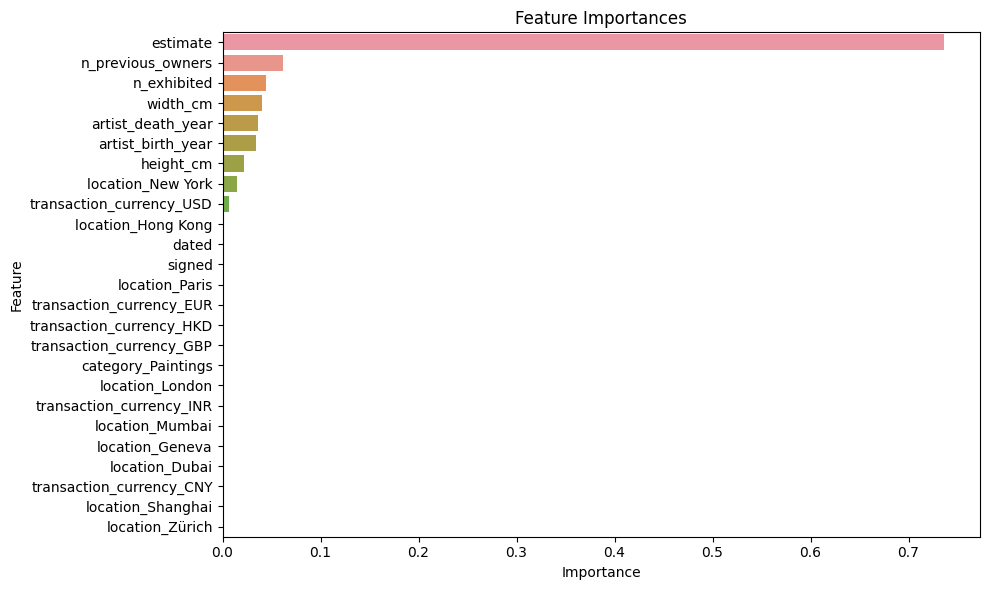

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

In [25]:
print("Most important feature:", feature_importance_df.iloc[0]['Feature'])
print("Least important feature:", feature_importance_df.iloc[-1]['Feature'])

Most important feature: estimate
Least important feature: location_Zürich


In [26]:
pred = best_model.predict(test)

In [27]:
submission = pd.DataFrame({
    'object_id': ID,
    'price_realized': pred
})
submission.to_csv('submission.csv', index=False)

In [28]:
submission

,object_id,price_realized
0,gnite,4696.626717
1,agxtc,7555.699030
2,otrwd,26267.023078
3,yqyhe,14757.771579
4,cpqne,6207.916587
...,...,...
52946,yhuiq,10589.437865
52947,kwujo,346204.946375
52948,wyapo,56136.643960
52949,ebiyn,21974.261607
